In [13]:
import pandas as pd
import numpy as np
from web3 import Web3
import time

In [14]:
df = pd.read_csv('run2.csv.gz', compression='gzip')
display(df)

,block_number,reserve0,reserve1,total_supply,gas_used
0,10092348,0,0,0,229910
1,10092366,565606,5829,57418,110936
2,10096379,368593,3799,37418,118242
3,10099386,309317831,3188065,31400635,118252
4,10099386,415491243,4282369,42178909,92958
...,...,...,...,...,...
102058,23493096,3103044896031,3248704712,68401307273,93016
102059,23493122,3103033897026,3248716262,68401307273,93016
102060,23493488,3103026065401,3248724486,68401307273,93016
102061,23493812,3103014594199,3248736532,68401307273,93016


In [15]:
len(df)

102063

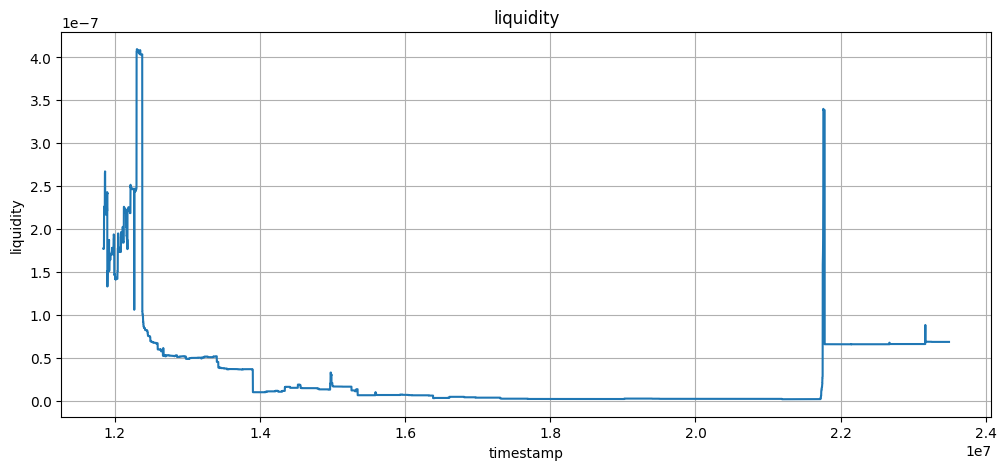

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df['block_number'].values[34021:102063], df['total_supply'].values[34021:102063]/10**18)
plt.xlabel('timestamp')
plt.ylabel('liquidity')
plt.title('liquidity')
plt.grid(True)
plt.show()

In [3]:
NODE_URL = 'https://ethereum-rpc.publicnode.com'
w3 = Web3(Web3.HTTPProvider(NODE_URL))
#timestamp = w3.eth.get_block(block_identifier=int(blocknumber))['timestamp']

In [4]:
event_history = {
    'timestamp': [],
    'type': [],
    'token0': [],
    'token1': [],
    'lp_token': [],
    'gas': []
}

is_init = True

for index, row in df.iterrows():

    blocknumber = row['block_number']

    if blocknumber < 11500000:
        continue
    
    if blocknumber >= 11500000 and is_init:
        init_reserve0 = row['reserve0']
        init_reserve1 = row['reserve1']
        init_total_supply = row['total_supply']
        reserve0 = row['reserve0']
        reserve1 = row['reserve1']
        total_supply = row['total_supply']
        is_init = False
        continue

    timestamp = w3.eth.get_block(block_identifier=int(blocknumber))['timestamp']
    current_reserve0 = row['reserve0']
    current_reserve1 = row['reserve1']
    current_total_supply = row['total_supply']
    event_history['timestamp'].append(timestamp)
    event_history['gas'].append(row['gas_used']) 

    if current_total_supply == total_supply:
        event_history['type'].append('swap')
        event_history['lp_token'].append(0)
        if current_reserve0 > reserve0:
            event_history['token0'].append(current_reserve0 - reserve0)
            event_history['token1'].append(0)
        else:
            event_history['token0'].append(0)
            event_history['token1'].append(current_reserve1 - reserve1)
    else:
        if current_total_supply > total_supply:
            event_history['type'].append('add_liquidity')
            event_history['token0'].append(current_reserve0 - reserve0)
            event_history['token1'].append(current_reserve1 - reserve1)
            event_history['lp_token'].append(current_total_supply - total_supply)
        else:
            event_history['type'].append('withdraw_liquidity')
            event_history['token0'].append(0)
            event_history['token1'].append(0)
            event_history['lp_token'].append(total_supply - current_total_supply)
    
    reserve0 = current_reserve0
    reserve1 = current_reserve1
    total_supply = current_total_supply

In [5]:
print(init_reserve0)
print(init_reserve1)
print(init_total_supply)
display(event_history)

2127929466229
9360290788
137916663049


{'timestamp': [1608597576,
  1608597851,
  1608598600,
  1608599002,
  1608599178,
  1608600109,
  1608600196,
  1608600462,
  1608600502,
  1608600551,
  1608601017,
  1608601068,
  1608601450,
  1608601569,
  1608602403,
  1608602491,
  1608603079,
  1608603423,
  1608604017,
  1608604526,
  1608604962,
  1608605220,
  1608605572,
  1608605576,
  1608605733,
  1608606704,
  1608606810,
  1608606822,
  1608607655,
  1608607699,
  1608607704,
  1608607826,
  1608607962,
  1608608158,
  1608608580,
  1608609817,
  1608610262,
  1608612106,
  1608613423,
  1608613620,
  1608613875,
  1608614551,
  1608614595,
  1608614681,
  1608614717,
  1608615776,
  1608616007,
  1608616118,
  1608617185,
  1608617440,
  1608617726,
  1608617932,
  1608618467,
  1608619792,
  1608620068,
  1608621253,
  1608621794,
  1608622393,
  1608623133,
  1608623604,
  1608623903,
  1608623914,
  1608624545,
  1608624863,
  1608625040,
  1608625541,
  1608625697,
  1608625956,
  1608626148,
  1608626665,
  16086

In [6]:
df_history = pd.DataFrame(event_history)

In [7]:
df_history.to_csv('history_event_expanded.csv', index=False)